In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [15]:
df = pd.read_csv(r"C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\prediction.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [16]:
# ------------------------------------------------------------
# Select placed students
# ------------------------------------------------------------
placed_df = df[df["Salary Package"] > 0].copy()

print("Placed students:", len(placed_df))



Placed students: 32924


In [17]:
# ------------------------------------------------------------
# Simple Linear Regression
# X = CGPA
# y = Salary Package
# ------------------------------------------------------------
X = placed_df[["CGPA"]]
y = placed_df["Salary Package"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (26339, 1)
X_test : (6585, 1)
y_train: (26339,)
y_test : (6585,)


In [18]:
#Standardize CGPA for Gradient Descent


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original CGPA:")
print(X_train.head())

print("\nStandardized CGPA:")
print(X_train_scaled[:5])

Original CGPA:
        CGPA
40542  10.00
44517   8.18
20861   6.25
3480    9.15
11151   7.42

Standardized CGPA:
[[ 1.54661158]
 [ 0.13512655]
 [-1.36166801]
 [ 0.88740154]
 [-0.45428478]]


In [19]:
#Batch Gradient Descent from scratch

# Convert to NumPy arrays
X_gd = X_train_scaled.flatten()
y_gd = y_train.to_numpy()

m = len(X_gd)

# Initialize parameters
theta_0 = 0.0
theta_1 = 0.0

learning_rate = 0.01
epochs = 1000

loss_history = []

# ------------------------------------------------------------
# Batch Gradient Descent
# ------------------------------------------------------------
for epoch in range(epochs):

    # Prediction
    y_pred = theta_0 + theta_1 * X_gd
    print(" theta_0:", theta_0)
    print(" theta_1:", theta_1)

    # Error
    error = y_pred - y_gd

    # MSE
    mse = np.mean(error ** 2)
    loss_history.append(mse)

    # Gradients
    gradient_theta_0 = (2 / m) * np.sum(error)
    gradient_theta_1 = (2 / m) * np.sum(error * X_gd)

    # Parameter update
    theta_0 -= learning_rate * gradient_theta_0
    theta_1 -= learning_rate * gradient_theta_1

print("Final theta_0:", theta_0)
print("Final theta_1:", theta_1)
print("Final training MSE:", loss_history[-1])

 theta_0: 0.0
 theta_1: 0.0
 theta_0: 0.2897377121378944
 theta_1: 0.10599093990444651
 theta_0: 0.5736806700330309
 theta_1: 0.2098620610108041
 theta_0: 0.8519447687702648
 theta_1: 0.3116557596950345
 theta_0: 1.124643585532754
 theta_1: 0.4114135844055803
 theta_0: 1.3918884259599933
 theta_1: 0.5091762526219152
 theta_0: 1.653788369578688
 theta_1: 0.6049836674739234
 theta_0: 1.9104503143250087
 theta_1: 0.6988749340288914
 theta_0: 2.161979020176403
 theta_1: 0.7908883752527601
 theta_0: 2.4084771519107693
 theta_1: 0.8810615476521514
 theta_0: 2.6500453210104484
 theta_1: 0.9694312566035549
 theta_0: 2.886782126728134
 theta_1: 1.0560335713759303
 theta_0: 3.1187841963314655
 theta_1: 1.1409038398528581
 theta_0: 3.3461462245427307
 theta_1: 1.2240767029602475
 theta_0: 3.5689610121897704
 theta_1: 1.305586108805489
 theta_0: 3.7873195040838694
 theta_1: 1.3854653265338257
 theta_0: 4.001310826140086
 theta_1: 1.4637469599075956
 theta_0: 4.211022321755179
 theta_1: 1.540462960

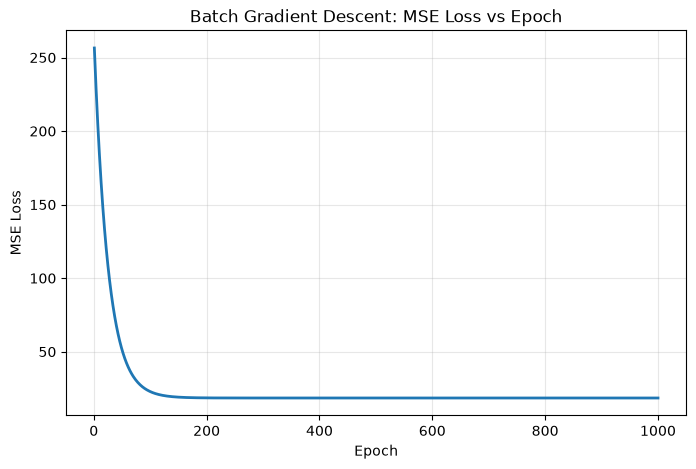

In [20]:
#MSE Curve loss

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Batch Gradient Descent: MSE Loss vs Epoch")
plt.grid(True, alpha=0.3)

plt.show()

In [21]:
X_test_gd = X_test_scaled.flatten()

y_test_pred_gd = theta_0 + theta_1 * X_test_gd

gd_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_gd)
)

gd_mae = mean_absolute_error(
    y_test,
    y_test_pred_gd
)

gd_r2 = r2_score(
    y_test,
    y_test_pred_gd
)

print("Batch GD RMSE:", gd_rmse)
print("Batch GD MAE :", gd_mae)
print("Batch GD R²  :", gd_r2)

Batch GD RMSE: 4.278633635327304
Batch GD MAE : 3.384857301464024
Batch GD R²  : 0.6080779825589153


In [22]:
#Compare with sklearn LinearRegression
sk_model = LinearRegression()

sk_model.fit(
    X_train_scaled,
    y_train
)

y_test_pred_sk = sk_model.predict(
    X_test_scaled
)

sk_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_sk)
)

sk_mae = mean_absolute_error(
    y_test,
    y_test_pred_sk
)

sk_r2 = r2_score(
    y_test,
    y_test_pred_sk
)

print("Sklearn RMSE:", sk_rmse)
print("Sklearn MAE :", sk_mae)
print("Sklearn R²  :", sk_r2)

Sklearn RMSE: 4.278633635207017
Sklearn MAE : 3.384857302533293
Sklearn R²  : 0.6080779825809519


In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Batch Gradient Descent",
        "sklearn LinearRegression"
    ],
    "RMSE": [
        gd_rmse,
        sk_rmse
    ],
    "MAE": [
        gd_mae,
        sk_mae
    ],
    "R²": [
        gd_r2,
        sk_r2
    ]
})

display(comparison)

,Model,RMSE,MAE,R²
0,Batch Gradient Descent,4.278634,3.384857,0.608078
1,sklearn LinearRegression,4.278634,3.384857,0.608078


## Using "Mini-Batch Gradient Descent" 

In [13]:
# ------------------------------------------------------------
# Mini-Batch Gradient Descent
# ------------------------------------------------------------

X_mb = X_train_scaled.flatten()
y_mb = y_train.to_numpy()

batch_size = 32
epochs_mb = 1000
learning_rate_mb = 0.01

theta_0_mb = 0.0
theta_1_mb = 0.0

mini_batch_loss = []

rng = np.random.default_rng(42)

n_samples = len(X_mb)

for epoch in range(epochs_mb):

    # Shuffle training data
    indices = rng.permutation(n_samples)

    X_shuffled = X_mb[indices]
    y_shuffled = y_mb[indices]

    # Process mini-batches
    for start in range(0, n_samples, batch_size):

        end = start + batch_size

        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        batch_n = len(X_batch)

        # Prediction
        y_batch_pred = (
            theta_0_mb +
            theta_1_mb * X_batch
        )

        # Error
        error = y_batch_pred - y_batch

        # Gradients
        grad_0 = (2 / batch_n) * np.sum(error)

        grad_1 = (
            (2 / batch_n) *
            np.sum(error * X_batch)
        )

        # Update
        theta_0_mb -= learning_rate_mb * grad_0
        theta_1_mb -= learning_rate_mb * grad_1

    # Calculate full training loss after each epoch
    y_epoch_pred = (
        theta_0_mb +
        theta_1_mb * X_mb
    )

    epoch_mse = np.mean(
        (y_epoch_pred - y_mb) ** 2
    )

    mini_batch_loss.append(epoch_mse)

print("Final theta_0:", theta_0_mb)
print("Final theta_1:", theta_1_mb)
print("Final MSE:", mini_batch_loss[-1])

Final theta_0: 14.61840774586733
Final theta_1: 5.323751467693646
Final MSE: 18.545810926198467


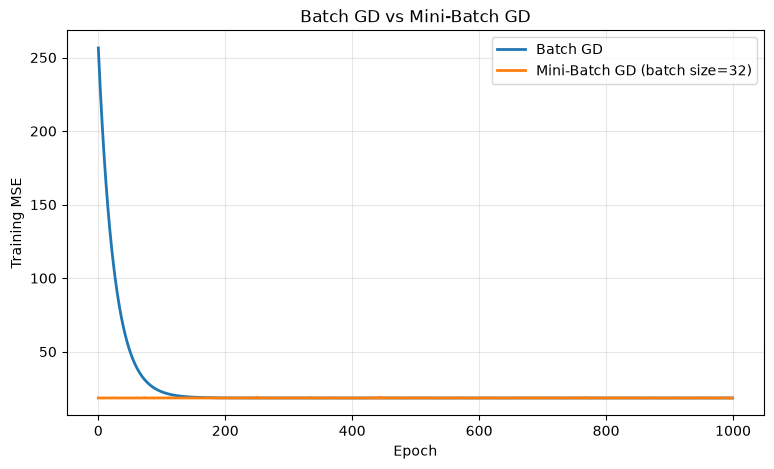

In [24]:
plt.figure(figsize=(9, 5))

plt.plot(
    loss_history,
    label="Batch GD",
    linewidth=2
)

plt.plot(
    mini_batch_loss,
    label="Mini-Batch GD (batch size=32)",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Batch GD vs Mini-Batch GD")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()